In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
n = 10000
df =pd.DataFrame()
df['timestamp'] = pd.date_range(start='2024-01-01', periods=n, freq='T')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22072\2071649211.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df['timestamp'] = pd.date_range(start='2024-01-01', periods=n, freq='T')


In [3]:
np.random.seed(42)

df['temperature'] = np.random.normal(75, 3, n)
df['vibrations'] = np.random.normal(0.5, 0.05, n)
df['rpm'] = np.random.normal(2000, 100, n)
df['consumption'] = np.random.normal(10, 1, n)

df

,timestamp,temperature,vibrations,rpm,consumption
0,2024-01-01 00:00:00,76.490142,0.466075,2034.828625,8.019428
1,2024-01-01 00:01:00,74.585207,0.484725,2028.332359,8.945014
2,2024-01-01 00:02:00,76.943066,0.470131,1906.348015,9.412972
3,2024-01-01 00:03:00,79.569090,0.505521,2057.958422,10.149669
4,2024-01-01 00:04:00,74.297540,0.559859,1850.991732,11.024162
...,...,...,...,...,...
9995,2024-01-07 22:35:00,78.903306,0.519391,1942.271215,11.119651
9996,2024-01-07 22:36:00,69.004965,0.568868,2144.460398,10.265034
9997,2024-01-07 22:37:00,72.884050,0.518918,1949.863268,10.616501
9998,2024-01-07 22:38:00,76.487297,0.585676,1810.764318,10.814624


In [4]:
anomaly_indices = np.random.choice(n, size=int(0.05 * n), replace=False)

df.loc[anomaly_indices, 'temperature'] += np.random.normal(20, 5, len(anomaly_indices))

df.loc[anomaly_indices, 'vibrations'] += np.random.normal(0.3, 0.1, len(anomaly_indices))

df.loc[anomaly_indices, 'rpm'] -= np.random.normal(500, 100, len(anomaly_indices))

In [6]:
df['anomaly'] = 0
df.loc[anomaly_indices, 'anomaly'] = 1

In [7]:
for i in range(100, 200):
    df.loc[i, 'temperature'] += (i - 100) * 0.2

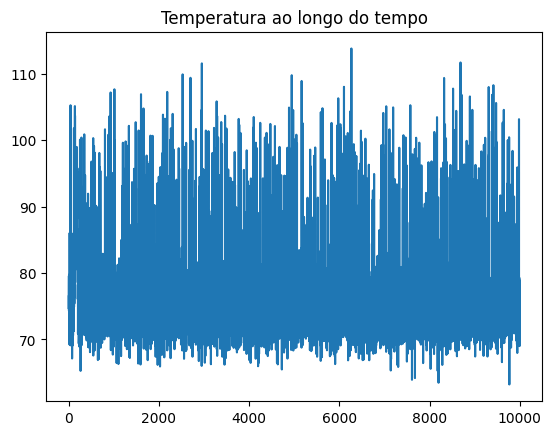

In [8]:
plt.plot(df['temperature'])
plt.title("Temperatura ao longo do tempo")
plt.show()